# Random Forest Experiments

This notebook documents all Random Forest experiments on the fraud detection dataset.
Each experiment is run on **two feature sets** to compare the effect of feature selection:

| Label | Source | Features |
|-------|--------|----------|
| **Partially Selected (PS)** | `data/processed/partially_selected_features.csv` | 33 features (all after column cleanup) |
| **Selected (S)** | `data/processed/selected_features.csv` | 20 features (MRMR-selected subset) |

**Split strategy:** 70% train / 15% validation / 15% test (stratified, `random_state=42`)

Both pipelines use the same `random_state=42` and identical split ratios, so the same rows
land in train/validation/test. The only difference is the feature set.

**Why Random Forest?** Unlike logistic regression (a linear model), Random Forest is an ensemble
of decision trees that can capture non-linear relationships and feature interactions without
explicit feature engineering. It is also robust to feature scaling (trees split on thresholds,
not distances), so we skip the StandardScaler step used in logistic regression.

**Note on scaling:** Random Forest is invariant to monotonic transformations of features.
Scaling does not affect tree splits, so we use the encoded (but unscaled) data directly.

In [14]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, f1_score
)
import warnings
warnings.filterwarnings('ignore')

from src.data.load_data import load_selected_features
from src.data.preprocess import encode_target, encode_categoricals, split_data
from src.models.predict import predict, predict_proba
from src.evaluation.metrics import evaluate_model, print_metrics

print('Imports loaded successfully.')

Imports loaded successfully.


## Data Preparation

We load both feature sets and apply the same preprocessing pipeline:
1. **Label encoding** for categorical features — converts string categories to integers
2. **Stratified train/val/test split** — 70/15/15 ratio, preserving class balance in each set

**No scaling needed.** Random Forest uses threshold-based splits at each tree node.
The split decision (`feature_i <= threshold`) is unaffected by scaling or shifting.
This is a key advantage over logistic regression, which requires scaled features for
proper gradient optimization and fair regularization.

In [15]:
def prepare_dataset(path, label):
    df = load_selected_features(path)
    print(f"\n{'='*60}")
    print(f"{label} — {path}")
    print(f"{'='*60}")
    print(f"Shape: {df.shape}")
    print(f"Class distribution:\n{df['fraud_reported'].value_counts()}")
    print(f"Fraud rate: {(df['fraud_reported'] == 'Y').mean()*100:.1f}%")

    X = df.drop(columns=['fraud_reported'])
    y = encode_target(df['fraud_reported'])

    X_encoded, encoders = encode_categoricals(X)
    cat_cols = X.select_dtypes(include=['object']).columns.tolist()
    num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    print(f"\nCategorical features ({len(cat_cols)}): {cat_cols}")
    print(f"Numerical features ({len(num_cols)}): {num_cols}")

    X_train, X_val, X_test, y_train, y_val, y_test = split_data(
        X_encoded, y, test_size=0.15, val_size=0.15, random_state=42
    )
    print(f"\nTrain: {X_train.shape[0]}  |  Val: {X_val.shape[0]}  |  Test: {X_test.shape[0]}")

    return {
        'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
        'y_train': y_train, 'y_val': y_val, 'y_test': y_test,
        'label': label,
    }

ds_ps = prepare_dataset('../data/processed/partially_selected_features.csv', 'Partially Selected (33 feat.)')
ds_s  = prepare_dataset('../data/processed/selected_features.csv', 'Selected / MRMR (20 feat.)')

datasets = [ds_ps, ds_s]


Partially Selected (33 feat.) — ../data/processed/partially_selected_features.csv
Shape: (1000, 34)
Class distribution:
fraud_reported
N    753
Y    247
Name: count, dtype: int64
Fraud rate: 24.7%

Categorical features (17): ['policy_state', 'policy_csl', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'property_damage', 'police_report_available', 'auto_make', 'auto_model']
Numerical features (16): ['months_as_customer', 'age', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'capital-gains', 'capital-loss', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_year']

Train: 700  |  Val: 150  |  Test: 150

Selected / MRMR (20 feat.) — ../data/processed/selected_features.csv
Shape: (1

---
## Run 1: Baseline Random Forest

**Goal:** Establish a baseline with reasonable default parameters on both feature sets.

**Configuration:**
- `n_estimators=100` — number of trees in the forest. 100 is a common default that balances
  performance and training time. Each tree is trained on a bootstrap sample of the data.
- `class_weight='balanced'` — adjusts sample weights inversely proportional to class frequencies,
  same rationale as logistic regression: without this, the model optimizes for the majority class
  and misses most fraud cases.
- `max_depth=None` — trees grow until all leaves are pure or contain fewer than `min_samples_split`
  samples. No depth limit means individual trees can overfit, but the ensemble averaging reduces
  variance (this is the core idea behind bagging).
- `random_state=42` — reproducibility.

**Why balanced class weights?** Same as logistic regression: in fraud detection, a false negative
(missing fraud) is more costly than a false positive (flagging a legitimate claim). Balanced
weights make misclassifying a fraud case ~3x more costly (proportional to 750/250).

In [16]:
for ds in datasets:
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    model.fit(ds['X_train'], ds['y_train'])
    ds['model_v1'] = model
    ds['results_log'] = []

    print(f"\n{'='*60}")
    print(f"{ds['label']}")
    print(f"{'='*60}")
    for name, X_set, y_set in [('Train', ds['X_train'], ds['y_train']),
                                ('Validation', ds['X_val'], ds['y_val'])]:
        y_pred = predict(model, X_set)
        y_prob = predict_proba(model, X_set)
        res = evaluate_model(y_set, y_pred, y_prob)
        print_metrics(res, name)
        print()
        if name == 'Validation':
            ds['val_res_v1'] = res

    ds['results_log'].append({
        'Run': 'V1: Baseline (100 trees, no depth limit)',
        'Val F1': ds['val_res_v1']['f1'],
        'Val Precision': ds['val_res_v1']['precision'],
        'Val Recall': ds['val_res_v1']['recall'],
        'Val ROC AUC': ds['val_res_v1']['roc_auc'],
    })


Partially Selected (33 feat.)
[Train] Accuracy:  1.0000
[Train] Precision: 1.0000
[Train] Recall:    1.0000
[Train] F1 Score:  1.0000
[Train] ROC AUC:   1.0000

[Validation] Accuracy:  0.7800
[Validation] Precision: 0.6667
[Validation] Recall:    0.2162
[Validation] F1 Score:  0.3265
[Validation] ROC AUC:   0.8370


Selected / MRMR (20 feat.)
[Train] Accuracy:  1.0000
[Train] Precision: 1.0000
[Train] Recall:    1.0000
[Train] F1 Score:  1.0000
[Train] ROC AUC:   1.0000

[Validation] Accuracy:  0.8000
[Validation] Precision: 0.6400
[Validation] Recall:    0.4324
[Validation] F1 Score:  0.5161
[Validation] ROC AUC:   0.8282



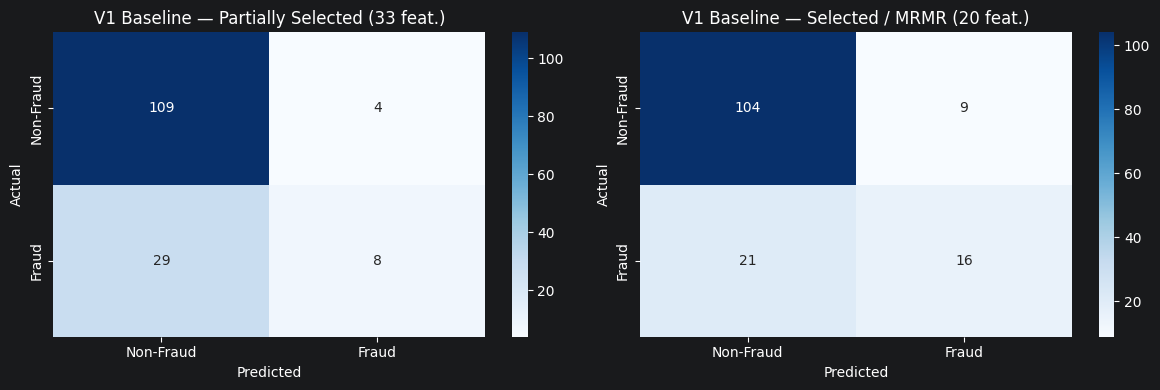

In [17]:
# Confusion matrices — baseline, side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, ds in zip(axes, datasets):
    y_pred = predict(ds['model_v1'], ds['X_val'])
    cm = confusion_matrix(ds['y_val'], y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
    ax.set_title(f'V1 Baseline — {ds["label"]}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

---
## Run 2: Cross-Validation to Assess Stability

**Goal:** Assess how stable the baseline Random Forest is across different data folds.

**Why cross-validation here?** With only 700 training samples, a single train/val split can be noisy.
5-fold CV gives us 5 different validation estimates, and the variance tells us how sensitive the
model is to which data ends up in train vs validation.

**Note:** Random Forest already has built-in variance reduction through bagging (each tree sees
a different bootstrap sample), so we expect lower variance across folds compared to a single
decision tree. CV confirms this.

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for ds in datasets:
    print(f"\n{'='*60}")
    print(f"{ds['label']}")
    print(f"{'='*60}")

    cv_model = RandomForestClassifier(
        n_estimators=100, max_depth=None, class_weight='balanced',
        random_state=42, n_jobs=-1
    )
    for metric in ['f1', 'precision', 'recall', 'roc_auc']:
        scores = cross_val_score(cv_model, ds['X_train'], ds['y_train'], cv=cv, scoring=metric)
        print(f"{metric:<12}: {scores.mean():.4f} (+/- {scores.std():.4f})  | folds: {[f'{s:.3f}' for s in scores]}")

print("\nInterpretation:")
print("- Low std means the model is stable across different data splits")
print("- Compare with logistic regression CV results to see if RF is more/less stable")


Partially Selected (33 feat.)
f1          : 0.2648 (+/- 0.0826)  | folds: ['0.286', '0.103', '0.333', '0.298', '0.304']
precision   : 0.5403 (+/- 0.0915)  | folds: ['0.467', '0.400', '0.615', '0.583', '0.636']
recall      : 0.1787 (+/- 0.0608)  | folds: ['0.206', '0.059', '0.229', '0.200', '0.200']
roc_auc     : 0.8360 (+/- 0.0235)  | folds: ['0.825', '0.839', '0.830', '0.807', '0.878']

Selected / MRMR (20 feat.)
f1          : 0.3922 (+/- 0.0998)  | folds: ['0.586', '0.383', '0.351', '0.327', '0.314']
precision   : 0.5610 (+/- 0.1152)  | folds: ['0.708', '0.692', '0.455', '0.450', '0.500']
recall      : 0.3072 (+/- 0.0981)  | folds: ['0.500', '0.265', '0.286', '0.257', '0.229']
roc_auc     : 0.8444 (+/- 0.0127)  | folds: ['0.850', '0.851', '0.833', '0.827', '0.862']

Interpretation:
- Low std means the model is stable across different data splits
- Compare with logistic regression CV results to see if RF is more/less stable


---
## Run 3: Number of Trees (n_estimators)

**Goal:** Find the optimal number of trees.

**Why tune n_estimators?** More trees generally improve performance (lower variance) but with
diminishing returns. At some point, adding more trees only increases training time without
improving validation performance. We search across a range to find where performance plateaus.

**Method:** Evaluate on validation set for a range of tree counts. Unlike C tuning in logistic
regression, more trees rarely cause overfitting — the ensemble averaging prevents it.

In [19]:
n_estimators_values = [10, 50, 100, 200, 300, 500]

for ds in datasets:
    n_results = []
    for n in n_estimators_values:
        model_n = RandomForestClassifier(
            n_estimators=n, max_depth=None, class_weight='balanced',
            random_state=42, n_jobs=-1
        )
        model_n.fit(ds['X_train'], ds['y_train'])

        y_pred_val = predict(model_n, ds['X_val'])
        y_prob_val = predict_proba(model_n, ds['X_val'])
        val_res = evaluate_model(ds['y_val'], y_pred_val, y_prob_val)

        y_pred_train = predict(model_n, ds['X_train'])
        train_f1 = f1_score(ds['y_train'], y_pred_train)

        n_results.append({
            'n_estimators': n,
            'Train F1': train_f1,
            'Val F1': val_res['f1'],
            'Val Precision': val_res['precision'],
            'Val Recall': val_res['recall'],
            'Val ROC AUC': val_res['roc_auc'],
        })

    n_df = pd.DataFrame(n_results)
    ds['n_df'] = n_df
    ds['best_n'] = int(n_df.loc[n_df['Val F1'].idxmax(), 'n_estimators'])

    print(f"\n{'='*60}")
    print(f"{ds['label']}")
    print(f"{'='*60}")
    print(n_df.to_string(index=False))
    print(f"\nBest n_estimators by validation F1: {ds['best_n']}")


Partially Selected (33 feat.)
 n_estimators  Train F1   Val F1  Val Precision  Val Recall  Val ROC AUC
           10  0.976331 0.186047       0.666667    0.108108     0.797536
           50  0.997101 0.285714       0.583333    0.189189     0.836522
          100  1.000000 0.326531       0.666667    0.216216     0.837001
          200  1.000000 0.250000       0.545455    0.162162     0.818106
          300  1.000000 0.250000       0.545455    0.162162     0.818943
          500  1.000000 0.280000       0.538462    0.189189     0.828630

Best n_estimators by validation F1: 100

Selected / MRMR (20 feat.)
 n_estimators  Train F1   Val F1  Val Precision  Val Recall  Val ROC AUC
           10  0.985337 0.357143       0.526316    0.270270     0.825640
           50  0.997101 0.491803       0.625000    0.405405     0.810452
          100  1.000000 0.516129       0.640000    0.432432     0.828151
          200  1.000000 0.483871       0.600000    0.405405     0.830423
          300  1.000000 

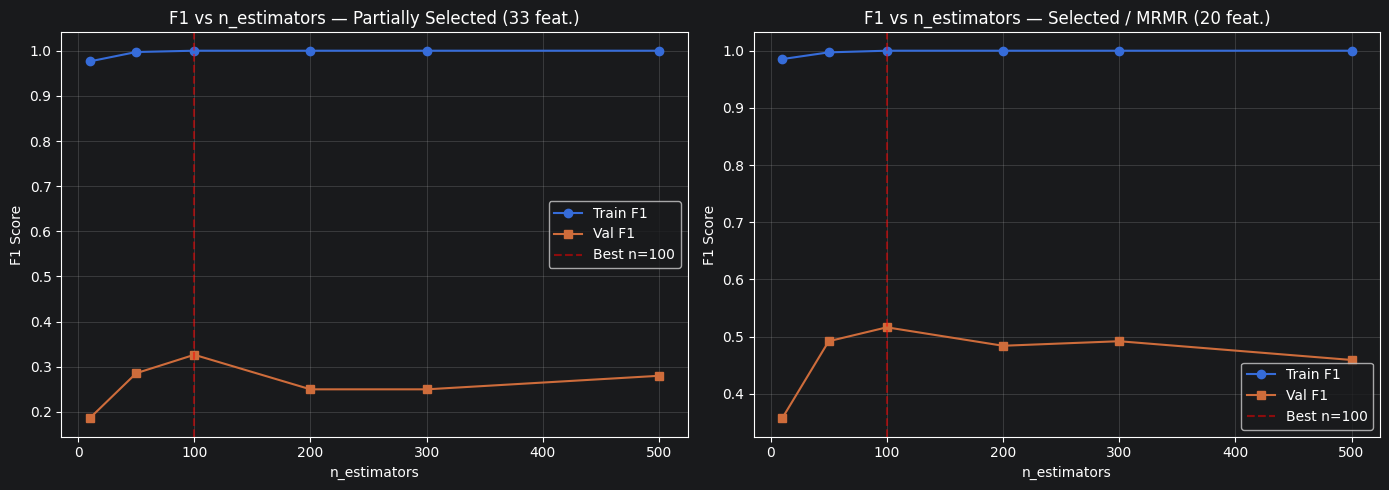

Note: Train F1 near 1.0 with unlimited depth is expected — each tree memorizes its bootstrap sample.
The ensemble still generalizes well because averaging many overfit trees reduces variance (bagging).


In [20]:
# Visualize n_estimators tuning
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ds in zip(axes, datasets):
    n_df = ds['n_df']
    ax.plot(n_df['n_estimators'], n_df['Train F1'], 'o-', label='Train F1')
    ax.plot(n_df['n_estimators'], n_df['Val F1'], 's-', label='Val F1')
    ax.axvline(x=ds['best_n'], color='red', linestyle='--', alpha=0.5,
               label=f'Best n={ds["best_n"]}')
    ax.set_xlabel('n_estimators')
    ax.set_ylabel('F1 Score')
    ax.set_title(f'F1 vs n_estimators — {ds["label"]}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Note: Train F1 near 1.0 with unlimited depth is expected — each tree memorizes its bootstrap sample.")
print("The ensemble still generalizes well because averaging many overfit trees reduces variance (bagging).")

---
## Run 4: Max Depth Tuning

**Goal:** Find the optimal tree depth to control overfitting.

**Why tune max_depth?** While the ensemble averaging in Random Forest already reduces variance,
individual trees with unlimited depth can memorize noise in the training data:
- **Shallow trees** (e.g., depth=3) = high bias, low variance (underfitting)
- **Deep trees** (e.g., depth=None) = low bias, high variance per tree (but ensemble reduces it)
- A moderate depth may give the best bias-variance trade-off

**Method:** Fix n_estimators at the best value from Run 3 and search over max_depth values.

In [21]:
depth_values = [3, 5, 7, 10, 15, 20, None]

for ds in datasets:
    d_results = []
    for d in depth_values:
        model_d = RandomForestClassifier(
            n_estimators=ds['best_n'], max_depth=d, class_weight='balanced',
            random_state=42, n_jobs=-1
        )
        model_d.fit(ds['X_train'], ds['y_train'])

        y_pred_val = predict(model_d, ds['X_val'])
        y_prob_val = predict_proba(model_d, ds['X_val'])
        val_res = evaluate_model(ds['y_val'], y_pred_val, y_prob_val)

        y_pred_train = predict(model_d, ds['X_train'])
        train_f1 = f1_score(ds['y_train'], y_pred_train)

        d_results.append({
            'max_depth': d if d is not None else 'None',
            'Train F1': train_f1,
            'Val F1': val_res['f1'],
            'Val Precision': val_res['precision'],
            'Val Recall': val_res['recall'],
            'Val ROC AUC': val_res['roc_auc'],
        })

    d_df = pd.DataFrame(d_results)
    ds['d_df'] = d_df
    best_idx = d_df['Val F1'].idxmax()
    ds['best_depth'] = depth_values[best_idx]

    print(f"\n{'='*60}")
    print(f"{ds['label']}")
    print(f"{'='*60}")
    print(d_df.to_string(index=False))
    print(f"\nBest max_depth by validation F1: {ds['best_depth']}")


Partially Selected (33 feat.)
max_depth  Train F1   Val F1  Val Precision  Val Recall  Val ROC AUC
        3  0.702842 0.609756       0.555556    0.675676     0.833772
        5  0.788660 0.698795       0.630435    0.783784     0.839990
        7  0.913649 0.631579       0.615385    0.648649     0.843578
       10  1.000000 0.524590       0.666667    0.432432     0.827314
       15  1.000000 0.326531       0.666667    0.216216     0.838555
       20  1.000000 0.291667       0.636364    0.189189     0.835446
     None  1.000000 0.326531       0.666667    0.216216     0.837001

Best max_depth by validation F1: 5

Selected / MRMR (20 feat.)
max_depth  Train F1   Val F1  Val Precision  Val Recall  Val ROC AUC
        3  0.694737 0.666667       0.613636    0.729730     0.846448
        5  0.777778 0.682927       0.622222    0.756757     0.824444
        7  0.880435 0.641026       0.609756    0.675676     0.829945
       10  1.000000 0.558824       0.612903    0.513514     0.836642
       1

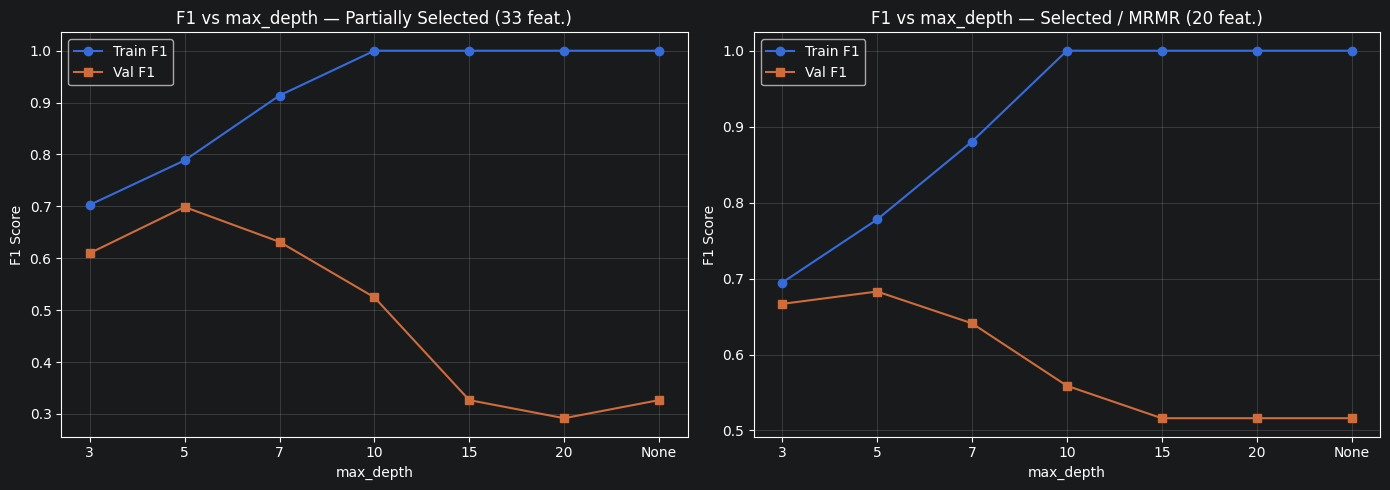

Note: The gap between Train F1 and Val F1 indicates overfitting.
Shallower trees reduce overfitting but may also reduce performance if too shallow.


In [22]:
# Visualize max_depth tuning
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ds in zip(axes, datasets):
    d_df = ds['d_df']
    x_labels = [str(v) for v in d_df['max_depth']]
    x_pos = range(len(x_labels))
    ax.plot(x_pos, d_df['Train F1'], 'o-', label='Train F1')
    ax.plot(x_pos, d_df['Val F1'], 's-', label='Val F1')
    ax.set_xticks(list(x_pos))
    ax.set_xticklabels(x_labels)
    ax.set_xlabel('max_depth')
    ax.set_ylabel('F1 Score')
    ax.set_title(f'F1 vs max_depth — {ds["label"]}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Note: The gap between Train F1 and Val F1 indicates overfitting.")
print("Shallower trees reduce overfitting but may also reduce performance if too shallow.")

---
## Run 5: Min Samples Split & Min Samples Leaf

**Goal:** Further control overfitting by requiring more samples to split a node or form a leaf.

**Why these parameters?**
- `min_samples_split` — minimum samples required to split a node. Higher values prevent the tree
  from creating splits on very small groups of samples (which are likely noise).
- `min_samples_leaf` — minimum samples in a leaf node. Ensures every prediction is based on a
  reasonable number of samples, smoothing the decision boundary.

**Method:** Fix n_estimators and max_depth at their best values, search over min_samples combinations.

In [23]:
min_samples_configs = [
    {'min_samples_split': 2,  'min_samples_leaf': 1},   # default
    {'min_samples_split': 5,  'min_samples_leaf': 2},
    {'min_samples_split': 10, 'min_samples_leaf': 4},
    {'min_samples_split': 20, 'min_samples_leaf': 8},
    {'min_samples_split': 30, 'min_samples_leaf': 10},
]

for ds in datasets:
    ms_results = []
    for cfg in min_samples_configs:
        model_ms = RandomForestClassifier(
            n_estimators=ds['best_n'], max_depth=ds['best_depth'],
            min_samples_split=cfg['min_samples_split'],
            min_samples_leaf=cfg['min_samples_leaf'],
            class_weight='balanced', random_state=42, n_jobs=-1
        )
        model_ms.fit(ds['X_train'], ds['y_train'])

        y_pred_val = predict(model_ms, ds['X_val'])
        y_prob_val = predict_proba(model_ms, ds['X_val'])
        val_res = evaluate_model(ds['y_val'], y_pred_val, y_prob_val)

        y_pred_train = predict(model_ms, ds['X_train'])
        train_f1 = f1_score(ds['y_train'], y_pred_train)

        ms_results.append({
            'min_split': cfg['min_samples_split'],
            'min_leaf': cfg['min_samples_leaf'],
            'Train F1': train_f1,
            'Val F1': val_res['f1'],
            'Val Precision': val_res['precision'],
            'Val Recall': val_res['recall'],
            'Val ROC AUC': val_res['roc_auc'],
        })

    ms_df = pd.DataFrame(ms_results)
    ds['ms_df'] = ms_df
    best_idx = ms_df['Val F1'].idxmax()
    ds['best_min_split'] = min_samples_configs[best_idx]['min_samples_split']
    ds['best_min_leaf'] = min_samples_configs[best_idx]['min_samples_leaf']

    print(f"\n{'='*60}")
    print(f"{ds['label']}")
    print(f"{'='*60}")
    print(ms_df.to_string(index=False))
    print(f"\nBest: min_samples_split={ds['best_min_split']}, min_samples_leaf={ds['best_min_leaf']}")


Partially Selected (33 feat.)
 min_split  min_leaf  Train F1   Val F1  Val Precision  Val Recall  Val ROC AUC
         2         1  0.788660 0.698795       0.630435    0.783784     0.839990
         5         2  0.772727 0.666667       0.613636    0.729730     0.838316
        10         4  0.761421 0.682927       0.622222    0.756757     0.836164
        20         8  0.729592 0.650000       0.604651    0.702703     0.837120
        30        10  0.729592 0.658537       0.600000    0.729730     0.828749

Best: min_samples_split=2, min_samples_leaf=1

Selected / MRMR (20 feat.)
 min_split  min_leaf  Train F1   Val F1  Val Precision  Val Recall  Val ROC AUC
         2         1  0.777778 0.682927       0.622222    0.756757     0.824444
         5         2  0.766917 0.682927       0.622222    0.756757     0.835207
        10         4  0.759305 0.698795       0.630435    0.783784     0.841904
        20         8  0.735516 0.698795       0.630435    0.783784     0.844535
        30    

---
## Run 6: Best Configuration with Cross-Validation Confirmation

**Goal:** Confirm the best hyperparameters found in Runs 3-5 are genuinely better, not just
lucky on this particular validation split.

**Method:** Run 5-fold stratified CV with the best configuration on the training data.

In [24]:
for ds in datasets:
    model_v2 = RandomForestClassifier(
        n_estimators=ds['best_n'],
        max_depth=ds['best_depth'],
        min_samples_split=ds['best_min_split'],
        min_samples_leaf=ds['best_min_leaf'],
        class_weight='balanced',
        random_state=42, n_jobs=-1
    )

    cv_scores = cross_val_score(model_v2, ds['X_train'], ds['y_train'], cv=cv, scoring='f1')

    print(f"\n{'='*60}")
    print(f"{ds['label']}")
    print(f"{'='*60}")
    print(f"Config: n_estimators={ds['best_n']}, max_depth={ds['best_depth']}, "
          f"min_split={ds['best_min_split']}, min_leaf={ds['best_min_leaf']}")
    print(f"CV F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

    model_v2.fit(ds['X_train'], ds['y_train'])
    ds['model_v2'] = model_v2

    for name, X_set, y_set in [('Train', ds['X_train'], ds['y_train']),
                                ('Validation', ds['X_val'], ds['y_val'])]:
        y_pred = predict(model_v2, X_set)
        y_prob = predict_proba(model_v2, X_set)
        res = evaluate_model(y_set, y_pred, y_prob)
        print_metrics(res, name)
        print()
        if name == 'Validation':
            ds['val_res_v2'] = res

    ds['results_log'].append({
        'Run': f'V2: Tuned (n={ds["best_n"]}, depth={ds["best_depth"]}, '
               f'split={ds["best_min_split"]}, leaf={ds["best_min_leaf"]})',
        'Val F1': ds['val_res_v2']['f1'],
        'Val Precision': ds['val_res_v2']['precision'],
        'Val Recall': ds['val_res_v2']['recall'],
        'Val ROC AUC': ds['val_res_v2']['roc_auc'],
    })


Partially Selected (33 feat.)
Config: n_estimators=100, max_depth=5, min_split=2, min_leaf=1
CV F1: 0.6032 (+/- 0.0584)
[Train] Accuracy:  0.8829
[Train] Precision: 0.7116
[Train] Recall:    0.8844
[Train] F1 Score:  0.7887
[Train] ROC AUC:   0.9600

[Validation] Accuracy:  0.8333
[Validation] Precision: 0.6304
[Validation] Recall:    0.7838
[Validation] F1 Score:  0.6988
[Validation] ROC AUC:   0.8400


Selected / MRMR (20 feat.)
Config: n_estimators=100, max_depth=5, min_split=10, min_leaf=4
CV F1: 0.6697 (+/- 0.0550)
[Train] Accuracy:  0.8614
[Train] Precision: 0.6652
[Train] Recall:    0.8844
[Train] F1 Score:  0.7593
[Train] ROC AUC:   0.9355

[Validation] Accuracy:  0.8333
[Validation] Precision: 0.6304
[Validation] Recall:    0.7838
[Validation] F1 Score:  0.6988
[Validation] ROC AUC:   0.8419



---
## Run 7: Threshold Tuning

**Goal:** The default classification threshold is 0.5, but this may not be optimal for imbalanced data.

**Why tune the threshold?** Random Forest outputs a probability (fraction of trees voting for fraud).
The threshold decides where we draw the line between "fraud" and "not fraud":
- **Lower threshold** (e.g., 0.3) = more fraud predictions = higher recall, lower precision
- **Higher threshold** (e.g., 0.7) = fewer fraud predictions = lower recall, higher precision

**Method:** Sweep thresholds from 0.1 to 0.9 on the validation set and pick the one that maximizes F1.

In [25]:
thresholds = np.arange(0.1, 0.91, 0.05)

for ds in datasets:
    y_prob_val = predict_proba(ds['model_v2'], ds['X_val'])
    threshold_results = []

    for t in thresholds:
        y_pred_t = (y_prob_val >= t).astype(int)
        if y_pred_t.sum() == 0 or y_pred_t.sum() == len(y_pred_t):
            continue
        res = evaluate_model(ds['y_val'], y_pred_t, y_prob_val)
        threshold_results.append({
            'Threshold': t,
            'Precision': res['precision'],
            'Recall': res['recall'],
            'F1': res['f1'],
            'Accuracy': res['accuracy'],
        })

    t_df = pd.DataFrame(threshold_results)
    ds['t_df'] = t_df
    ds['best_threshold'] = t_df.loc[t_df['F1'].idxmax(), 'Threshold']

    print(f"\n{'='*60}")
    print(f"{ds['label']}")
    print(f"{'='*60}")
    print(t_df.to_string(index=False))
    print(f"\nBest threshold by F1: {ds['best_threshold']:.2f}")


Partially Selected (33 feat.)
 Threshold  Precision   Recall       F1  Accuracy
      0.10   0.253425 1.000000 0.404372  0.273333
      0.15   0.268657 0.972973 0.421053  0.340000
      0.20   0.271318 0.945946 0.421687  0.360000
      0.25   0.286885 0.945946 0.440252  0.406667
      0.30   0.321101 0.945946 0.479452  0.493333
      0.35   0.412500 0.891892 0.564103  0.660000
      0.40   0.523810 0.891892 0.660000  0.773333
      0.45   0.600000 0.810811 0.689655  0.820000
      0.50   0.630435 0.783784 0.698795  0.833333
      0.55   0.600000 0.648649 0.623377  0.806667
      0.60   0.666667 0.486486 0.562500  0.813333
      0.65   0.625000 0.135135 0.222222  0.766667

Best threshold by F1: 0.50

Selected / MRMR (20 feat.)
 Threshold  Precision   Recall       F1  Accuracy
      0.10   0.251701 1.000000 0.402174  0.266667
      0.15   0.259259 0.945946 0.406977  0.320000
      0.20   0.280000 0.945946 0.432099  0.386667
      0.25   0.364583 0.945946 0.526316  0.580000
      0.30   

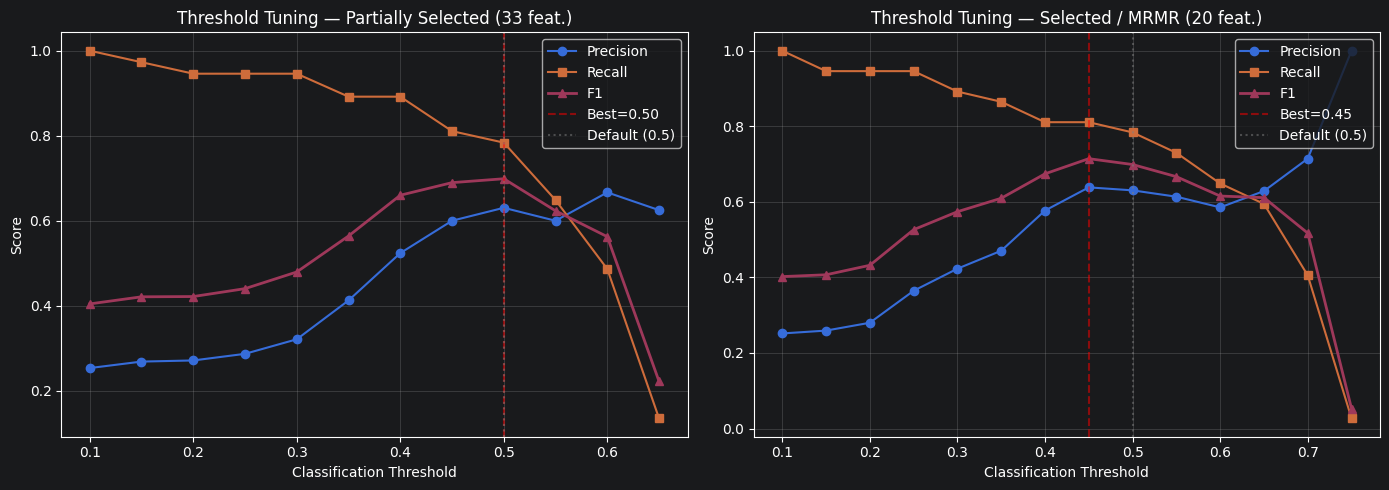

In [26]:
# Visualize threshold trade-off — both feature sets
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ds in zip(axes, datasets):
    t_df = ds['t_df']
    ax.plot(t_df['Threshold'], t_df['Precision'], 'o-', label='Precision')
    ax.plot(t_df['Threshold'], t_df['Recall'], 's-', label='Recall')
    ax.plot(t_df['Threshold'], t_df['F1'], '^-', label='F1', linewidth=2)
    ax.axvline(x=ds['best_threshold'], color='red', linestyle='--', alpha=0.5,
               label=f'Best={ds["best_threshold"]:.2f}')
    ax.axvline(x=0.5, color='gray', linestyle=':', alpha=0.5, label='Default (0.5)')
    ax.set_xlabel('Classification Threshold')
    ax.set_ylabel('Score')
    ax.set_title(f'Threshold Tuning — {ds["label"]}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
# Evaluate with best threshold on train + validation (test held out)
for ds in datasets:
    best_threshold = ds['best_threshold']
    print(f"\n{'='*60}")
    print(f"{ds['label']}  —  threshold = {best_threshold:.2f}")
    print(f"{'='*60}")

    for name, X_set, y_set in [('Train', ds['X_train'], ds['y_train']),
                                ('Validation', ds['X_val'], ds['y_val'])]:
        y_prob = predict_proba(ds['model_v2'], X_set)
        y_pred_t = (y_prob >= best_threshold).astype(int)
        res = evaluate_model(y_set, y_pred_t, y_prob)
        print_metrics(res, name)
        print()
        if name == 'Validation':
            ds['val_res_v3'] = res

    ds['results_log'].append({
        'Run': f'V3: Tuned + threshold={best_threshold:.2f}',
        'Val F1': ds['val_res_v3']['f1'],
        'Val Precision': ds['val_res_v3']['precision'],
        'Val Recall': ds['val_res_v3']['recall'],
        'Val ROC AUC': ds['val_res_v3']['roc_auc'],
    })


Partially Selected (33 feat.)  —  threshold = 0.50
[Train] Accuracy:  0.8829
[Train] Precision: 0.7116
[Train] Recall:    0.8844
[Train] F1 Score:  0.7887
[Train] ROC AUC:   0.9600

[Validation] Accuracy:  0.8333
[Validation] Precision: 0.6304
[Validation] Recall:    0.7838
[Validation] F1 Score:  0.6988
[Validation] ROC AUC:   0.8400


Selected / MRMR (20 feat.)  —  threshold = 0.45
[Train] Accuracy:  0.8600
[Train] Precision: 0.6596
[Train] Recall:    0.8960
[Train] F1 Score:  0.7598
[Train] ROC AUC:   0.9355

[Validation] Accuracy:  0.8400
[Validation] Precision: 0.6383
[Validation] Recall:    0.8108
[Validation] F1 Score:  0.7143
[Validation] ROC AUC:   0.8419



---
## Run 8: No Class Weighting (Comparison)

**Goal:** Understand the effect of `class_weight='balanced'` by removing it.

**Why this experiment?** Same rationale as logistic regression: we need to quantify how much
the balanced weighting helps. Without it, the model treats all misclassifications equally,
which on imbalanced data typically leads to higher accuracy but lower recall.

In [28]:
for ds in datasets:
    model_noweight = RandomForestClassifier(
        n_estimators=ds['best_n'], max_depth=ds['best_depth'],
        min_samples_split=ds['best_min_split'],
        min_samples_leaf=ds['best_min_leaf'],
        class_weight=None,
        random_state=42, n_jobs=-1
    )
    model_noweight.fit(ds['X_train'], ds['y_train'])

    print(f"\n{'='*60}")
    print(f"{ds['label']} — WITHOUT class_weight='balanced'")
    print(f"{'='*60}")
    y_pred = predict(model_noweight, ds['X_val'])
    y_prob = predict_proba(model_noweight, ds['X_val'])
    res = evaluate_model(ds['y_val'], y_pred, y_prob)
    print_metrics(res, 'Validation')
    print()

    ds['results_log'].append({
        'Run': 'V4: No class weighting',
        'Val F1': res['f1'],
        'Val Precision': res['precision'],
        'Val Recall': res['recall'],
        'Val ROC AUC': res['roc_auc'],
    })

print("Comparison: balanced vs no weighting shows the impact on recall (fraud detection rate)")


Partially Selected (33 feat.) — WITHOUT class_weight='balanced'
[Validation] Accuracy:  0.7533
[Validation] Precision: 0.5000
[Validation] Recall:    0.0541
[Validation] F1 Score:  0.0976
[Validation] ROC AUC:   0.8249


Selected / MRMR (20 feat.) — WITHOUT class_weight='balanced'
[Validation] Accuracy:  0.7867
[Validation] Precision: 0.6471
[Validation] Recall:    0.2973
[Validation] F1 Score:  0.4074
[Validation] ROC AUC:   0.8369

Comparison: balanced vs no weighting shows the impact on recall (fraud detection rate)


---
## Run Summary & Model Selection

Compare all experiment runs on **validation metrics only** for each feature set.
The test set has been held out throughout all tuning and will be evaluated exactly once below.

In [29]:
for ds in datasets:
    summary_df = pd.DataFrame(ds['results_log'])
    ds['summary_df'] = summary_df

    print(f"\n{'='*90}")
    print(f"EXPERIMENT LOG — {ds['label']}")
    print(f"{'='*90}")
    print(summary_df.to_string(index=False))

    best_idx = summary_df['Val F1'].idxmax()
    ds['best_run_name'] = summary_df.loc[best_idx, 'Run']
    print(f"\nBest run by Val F1: {ds['best_run_name']}")
    print(f"  Val F1:        {summary_df.loc[best_idx, 'Val F1']:.4f}")
    print(f"  Val Precision: {summary_df.loc[best_idx, 'Val Precision']:.4f}")
    print(f"  Val Recall:    {summary_df.loc[best_idx, 'Val Recall']:.4f}")
    print(f"  Val ROC AUC:   {summary_df.loc[best_idx, 'Val ROC AUC']:.4f}")


EXPERIMENT LOG — Partially Selected (33 feat.)
                                        Run   Val F1  Val Precision  Val Recall  Val ROC AUC
   V1: Baseline (100 trees, no depth limit) 0.326531       0.666667    0.216216     0.837001
V2: Tuned (n=100, depth=5, split=2, leaf=1) 0.698795       0.630435    0.783784     0.839990
                 V3: Tuned + threshold=0.50 0.698795       0.630435    0.783784     0.839990
                     V4: No class weighting 0.097561       0.500000    0.054054     0.824922

Best run by Val F1: V2: Tuned (n=100, depth=5, split=2, leaf=1)
  Val F1:        0.6988
  Val Precision: 0.6304
  Val Recall:    0.7838
  Val ROC AUC:   0.8400

EXPERIMENT LOG — Selected / MRMR (20 feat.)
                                         Run   Val F1  Val Precision  Val Recall  Val ROC AUC
    V1: Baseline (100 trees, no depth limit) 0.516129       0.640000    0.432432     0.828151
V2: Tuned (n=100, depth=5, split=10, leaf=4) 0.698795       0.630435    0.783784     0.841904

---
## Cross-Dataset Comparison (Validation Only)

Side-by-side comparison of the best run from each feature set on the validation set.
Both pipelines use the same random split, so the same rows are in validation — only
the features differ.

In [30]:
comparison_rows = []
for ds in datasets:
    best_idx = ds['summary_df']['Val F1'].idxmax()
    row = ds['summary_df'].iloc[best_idx].to_dict()
    row['Feature Set'] = ds['label']
    comparison_rows.append(row)

comp_df = pd.DataFrame(comparison_rows)
print("="*90)
print("BEST MODEL COMPARISON — Partially Selected (33) vs Selected/MRMR (20)")
print("="*90)
print(comp_df[['Feature Set', 'Run', 'Val F1', 'Val Precision', 'Val Recall', 'Val ROC AUC']].to_string(index=False))

for i in range(len(comp_df)):
    for j in range(i+1, len(comp_df)):
        r1, r2 = comp_df.iloc[i], comp_df.iloc[j]
        print(f"\nDelta ({r1['Feature Set'][:15]} vs {r2['Feature Set'][:15]}):")
        for m in ['Val F1', 'Val Precision', 'Val Recall', 'Val ROC AUC']:
            delta = r1[m] - r2[m]
            sign = '+' if delta >= 0 else ''
            print(f"  {m}: {sign}{delta:.4f}")

BEST MODEL COMPARISON — Partially Selected (33) vs Selected/MRMR (20)
                  Feature Set                                         Run   Val F1  Val Precision  Val Recall  Val ROC AUC
Partially Selected (33 feat.) V2: Tuned (n=100, depth=5, split=2, leaf=1) 0.698795       0.630435    0.783784     0.839990
   Selected / MRMR (20 feat.)                  V3: Tuned + threshold=0.45 0.714286       0.638298    0.810811     0.841904

Delta (PS - S):
  Val F1: -0.0155
  Val Precision: -0.0079
  Val Recall: -0.0270
  Val ROC AUC: -0.0019


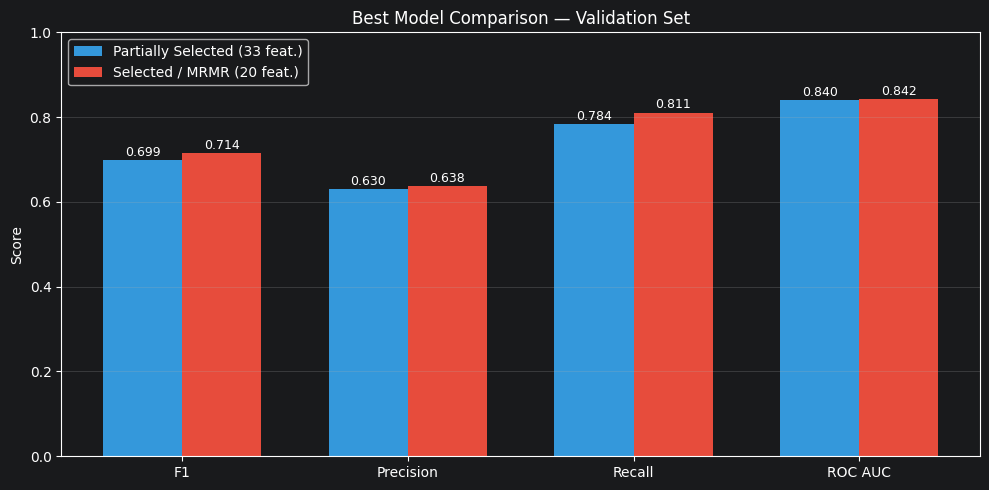

In [31]:
# Visual comparison — bar chart of validation metrics
metrics = ['Val F1', 'Val Precision', 'Val Recall', 'Val ROC AUC']
metric_labels = ['F1', 'Precision', 'Recall', 'ROC AUC']
bar_colors = ['#3498db', '#e74c3c', '#2ecc71']

x = np.arange(len(metrics))
n_bars = len(comp_df)
width = 0.8 / n_bars

fig, ax = plt.subplots(figsize=(12, 5))
for idx, (_, row) in enumerate(comp_df.iterrows()):
    vals = [row[m] for m in metrics]
    bars = ax.bar(x + (idx - n_bars/2 + 0.5) * width, vals, width,
                  label=row['Feature Set'][:20], color=bar_colors[idx % len(bar_colors)])
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)

ax.set_ylabel('Score')
ax.set_title('Best Model Comparison — Validation Set')
ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.legend(fontsize=8)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [32]:
# Full run-by-run comparison table
print("="*100)
print("FULL RUN-BY-RUN COMPARISON")
print("="*100)

ps_summary = datasets[0]['summary_df']
s_summary = datasets[1]['summary_df']

for run_name in ps_summary['Run']:
    ps_row = ps_summary[ps_summary['Run'] == run_name].iloc[0]
    s_row = s_summary[s_summary['Run'] == run_name].iloc[0] if run_name in s_summary['Run'].values else None

    print(f"\n--- {run_name} ---")
    print(f"{'Metric':<16} {'PS (33 feat.)':<16} {'S (20 feat.)':<16} {'Delta':<10}")
    for m in ['Val F1', 'Val Precision', 'Val Recall', 'Val ROC AUC']:
        ps_val = ps_row[m]
        if s_row is not None:
            s_val = s_row[m]
            delta = ps_val - s_val
            sign = '+' if delta >= 0 else ''
            print(f"{m:<16} {ps_val:<16.4f} {s_val:<16.4f} {sign}{delta:.4f}")
        else:
            print(f"{m:<16} {ps_val:<16.4f} {'N/A':<16}")

FULL RUN-BY-RUN COMPARISON

--- V1: Baseline (100 trees, no depth limit) ---
Metric           PS (33 feat.)    S (20 feat.)     Delta     
Val F1           0.3265           0.5161           -0.1896
Val Precision    0.6667           0.6400           +0.0267
Val Recall       0.2162           0.4324           -0.2162
Val ROC AUC      0.8370           0.8282           +0.0088

--- V2: Tuned (n=100, depth=5, split=2, leaf=1) ---
Metric           PS (33 feat.)    S (20 feat.)     Delta     
Val F1           0.6988           N/A             
Val Precision    0.6304           N/A             
Val Recall       0.7838           N/A             
Val ROC AUC      0.8400           N/A             

--- V3: Tuned + threshold=0.50 ---
Metric           PS (33 feat.)    S (20 feat.)     Delta     
Val F1           0.6988           N/A             
Val Precision    0.6304           N/A             
Val Recall       0.7838           N/A             
Val ROC AUC      0.8400           N/A             

---

---
## Final Test Evaluation (ONE-TIME)

**This is the only place in the notebook where the test set is used.**

After all hyperparameter tuning and model selection on the validation set, we evaluate the
best configuration on the held-out test set exactly once for each feature set. This gives
an unbiased estimate of how the model will perform on truly unseen data.

In [33]:
for ds in datasets:
    best_threshold = ds['best_threshold']

    print(f"\n{'='*60}")
    print(f"FINAL TEST — {ds['label']}")
    print(f"{'='*60}")
    print(f"Model: RandomForest(n={ds['best_n']}, depth={ds['best_depth']}, "
          f"split={ds['best_min_split']}, leaf={ds['best_min_leaf']}, balanced)")
    print(f"Threshold: {best_threshold:.2f}\n")

    y_prob_test = predict_proba(ds['model_v2'], ds['X_test'])
    y_pred_test = (y_prob_test >= best_threshold).astype(int)
    test_res = evaluate_model(ds['y_test'], y_pred_test, y_prob_test)
    print_metrics(test_res, 'Test')

    print("\nClassification Report:")
    print(classification_report(ds['y_test'], y_pred_test, target_names=['Non-Fraud', 'Fraud']))

    ds['test_res'] = test_res
    ds['y_prob_test'] = y_prob_test
    ds['y_pred_test'] = y_pred_test


FINAL TEST — Partially Selected (33 feat.)
Model: RandomForest(n=100, depth=5, split=2, leaf=1, balanced)
Threshold: 0.50

[Test] Accuracy:  0.8533
[Test] Precision: 0.6596
[Test] Recall:    0.8378
[Test] F1 Score:  0.7381
[Test] ROC AUC:   0.8469

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.94      0.86      0.90       113
       Fraud       0.66      0.84      0.74        37

    accuracy                           0.85       150
   macro avg       0.80      0.85      0.82       150
weighted avg       0.87      0.85      0.86       150


FINAL TEST — Selected / MRMR (20 feat.)
Model: RandomForest(n=100, depth=5, split=10, leaf=4, balanced)
Threshold: 0.45

[Test] Accuracy:  0.8400
[Test] Precision: 0.6226
[Test] Recall:    0.8919
[Test] F1 Score:  0.7333
[Test] ROC AUC:   0.8675

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.96      0.82      0.89       113
       Fraud       0

In [34]:
# Test set comparison table
print("="*80)
print("FINAL TEST COMPARISON — Partially Selected vs Selected/MRMR")
print("="*80)

test_comp = []
for ds in datasets:
    test_comp.append({
        'Feature Set': ds['label'],
        'Test F1': ds['test_res']['f1'],
        'Test Precision': ds['test_res']['precision'],
        'Test Recall': ds['test_res']['recall'],
        'Test ROC AUC': ds['test_res']['roc_auc'],
        'Test Accuracy': ds['test_res']['accuracy'],
    })

test_comp_df = pd.DataFrame(test_comp)
print(test_comp_df.to_string(index=False))

for i in range(len(test_comp_df)):
    for j in range(i+1, len(test_comp_df)):
        r1, r2 = test_comp_df.iloc[i], test_comp_df.iloc[j]
        print(f"\nDelta ({r1['Feature Set'][:15]} vs {r2['Feature Set'][:15]}):")
        for m in ['Test F1', 'Test Precision', 'Test Recall', 'Test ROC AUC', 'Test Accuracy']:
            delta = r1[m] - r2[m]
            sign = '+' if delta >= 0 else ''
            print(f"  {m}: {sign}{delta:.4f}")

FINAL TEST COMPARISON — Partially Selected vs Selected/MRMR
                  Feature Set  Test F1  Test Precision  Test Recall  Test ROC AUC  Test Accuracy
Partially Selected (33 feat.) 0.738095        0.659574     0.837838      0.846927       0.853333
   Selected / MRMR (20 feat.) 0.733333        0.622642     0.891892      0.867496       0.840000

Delta (PS - S):
  Test F1: +0.0048
  Test Precision: +0.0369
  Test Recall: -0.0541
  Test ROC AUC: -0.0206
  Test Accuracy: +0.0133


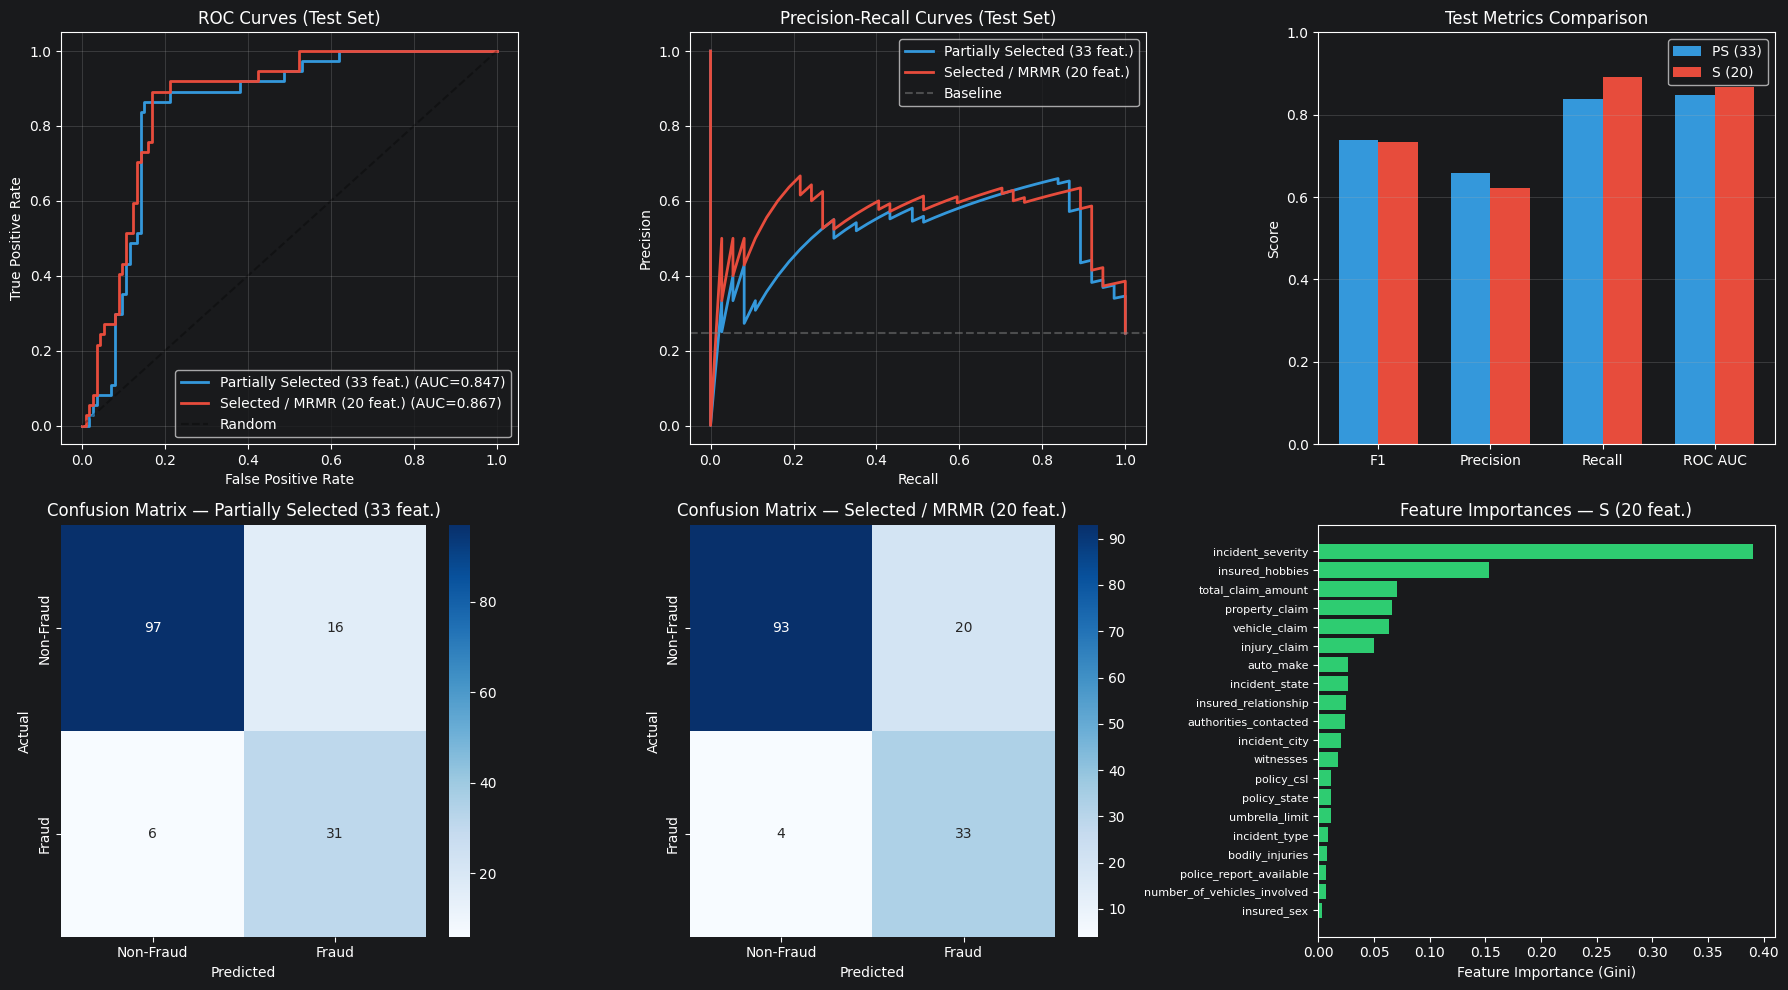

Feature importance = mean decrease in Gini impurity across all trees
Higher = more useful for distinguishing fraud from non-fraud


In [35]:
# Final visualizations — ROC, PR curve, confusion matrices
n_ds = len(datasets)
fig, axes = plt.subplots(2, max(n_ds, 2), figsize=(7*max(n_ds, 2), 10))
colors = ['#3498db', '#e74c3c', '#2ecc71']

# Row 0: ROC + PR
for i, ds in enumerate(datasets):
    fpr, tpr, _ = roc_curve(ds['y_test'], ds['y_prob_test'])
    roc_auc_val = auc(fpr, tpr)
    axes[0, 0].plot(fpr, tpr, color=colors[i], linewidth=2,
                    label=f'{ds["label"][:15]} (AUC={roc_auc_val:.3f})')
axes[0, 0].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
axes[0, 0].set_xlabel('False Positive Rate'); axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].set_title('ROC Curves (Test Set)'); axes[0, 0].legend(fontsize=7); axes[0, 0].grid(True, alpha=0.3)

for i, ds in enumerate(datasets):
    prec, rec, _ = precision_recall_curve(ds['y_test'], ds['y_prob_test'])
    axes[0, 1].plot(rec, prec, color=colors[i], linewidth=2, label=ds['label'][:15])
axes[0, 1].axhline(y=datasets[0]['y_test'].mean(), color='gray', linestyle='--', alpha=0.5, label='Baseline')
axes[0, 1].set_xlabel('Recall'); axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_title('PR Curves (Test Set)'); axes[0, 1].legend(fontsize=7); axes[0, 1].grid(True, alpha=0.3)

for j in range(2, max(n_ds, 2)):
    axes[0, j].set_visible(False)

# Row 1: Confusion matrices
for i, ds in enumerate(datasets):
    cm = confusion_matrix(ds['y_test'], ds['y_pred_test'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, i],
                xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
    axes[1, i].set_title(f'CM — {ds["label"][:20]}')
    axes[1, i].set_ylabel('Actual'); axes[1, i].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

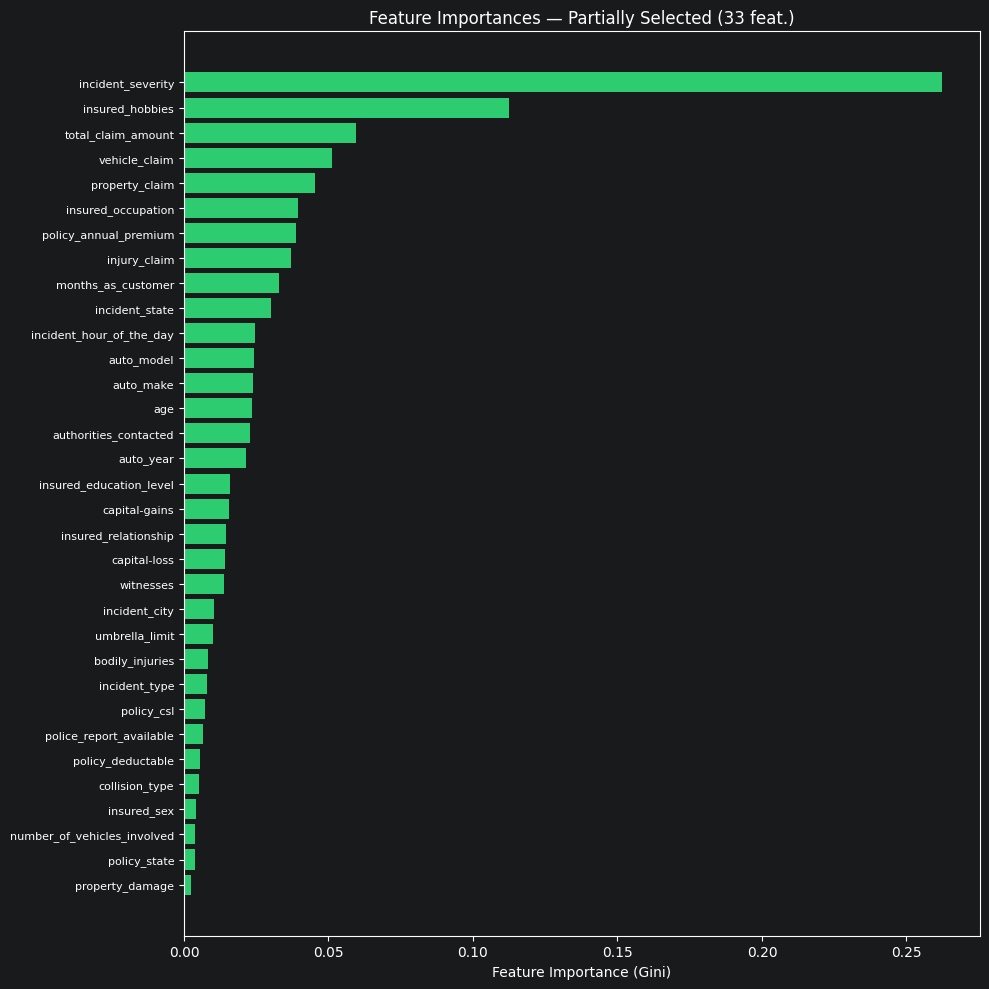

In [36]:
# Feature importances for Partially Selected model (33 features)
imp_df_ps = pd.DataFrame({
    'Feature': datasets[0]['X_train'].columns,
    'Importance': datasets[0]['model_v2'].feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 10))
plt.barh(range(len(imp_df_ps)), imp_df_ps['Importance'], color='#2ecc71')
plt.yticks(range(len(imp_df_ps)), imp_df_ps['Feature'], fontsize=8)
plt.xlabel('Feature Importance (Gini)')
plt.title('Feature Importances — Partially Selected (33 feat.)')
plt.tight_layout()
plt.show()